# This is the Make_sum_more model using Multi-layer perceptron.

In [1]:
import torch
from torch import nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline


In [2]:
#Read all of the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [3]:
len(words)

32033

In [4]:
#Build the vocab of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [5]:
#Build the dataset

block_size = 3 #context length, how many characters should we take to predict the next one
X, y = [], []
for w in words:
    # print(w)
    context = [0] * block_size
    for ch in w + '.': #for padding
        ix = stoi[ch]
        X.append(context)
        y.append(ix)
        # print(''.join(itos[i] for i in context), '--->', itos[ix])
        context = context[1:] + [ix] #crop and append

X = torch.tensor(X)
y = torch.tensor(y)

In [6]:
X.shape, X.dtype, y.shape, y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [7]:
C = torch.randn((27, 2)) #(rows, columns)

In [8]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [9]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [10]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [ ]:
h

tensor([[ 0.9557, -0.8151, -0.6960,  ...,  0.6302,  0.9995,  0.9993],
        [ 0.9975, -0.9021, -0.7348,  ...,  0.5242,  0.9995,  0.9982],
        [-0.0217, -0.9252, -0.1258,  ...,  0.8471,  1.0000,  0.9492],
        ...,
        [ 0.0783, -0.3906,  0.7863,  ...,  0.2688, -0.1843,  0.9958],
        [ 0.9760, -0.6933, -0.8373,  ..., -0.5746, -0.7935,  0.9996],
        [ 0.9454, -0.4513,  0.9784,  ...,  0.9902, -0.9968, -0.6726]])

In [12]:
h.shape

torch.Size([228146, 100])

In [13]:
W2 = torch.randn(100, 27)
b2 = torch.randn(27)

In [14]:
logits = h @ W2 + b2

In [43]:
counts = logits.exp()

In [44]:
prob = counts / counts.sum(1, keepdims=True)

In [45]:
prob[0].sum() #adds to one, so it normalized

tensor(1., grad_fn=<SumBackward0>)

In [46]:
y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [53]:
loss = -prob[torch.arange(32), y[ix]].log().mean()
loss

tensor(3.5006, grad_fn=<NegBackward0>)

In [68]:
F.cross_entropy(logits, y[ix])
parameters = [C, W1, b1, W2, b2]

In [69]:
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 2))
W1 = torch.randn((6, 100))
b1 = torch.randn(100)
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

parameters = [C, W1, b1, W2, b2]
for p in parameters:
    p.requires_grad = True

In [70]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [79]:
#training loop
lri = []
lossi = []

epochs = 10000
for i in range(epochs):
    #mini-batch constuct
    ix = torch.randint(0, X.shape[0], (32,))

    #forward pass
    emb = C[X[ix]] #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #[32, 100]
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, y[ix])
    # print(loss.item())
    #Backpropogation
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #lr is the learning rate

    #track stats
    # lri.append(lr)
    # lossi.append(loss.item())
# print(loss.item())



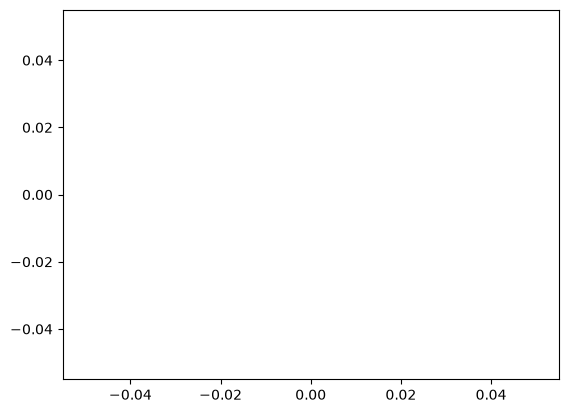

In [94]:
plt.plot(lri, lossi)

In [80]:
emb = C[X[ix]] #[32, 3, 2]
h = torch.tanh(emb.view(-1, 6) @ W1 + b1) #[32, 100]
logits = h @ W2 + b2
loss = F.cross_entropy(logits, y[ix])   
loss

tensor(1.8706, grad_fn=<NllLossBackward0>)

In [84]:
#Training split, validation split and test split
#80%, 10%, 10%  
def build_dataset(words):
    block_size = 3 #context length, how many characters do we want to take before we predict the next one?
    X, y = [], []
    for w in words:

        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            y.append(ix)

            context = context[1:] + [ix]

    X = torch.tensor(X)
    y = torch.tensor(y)
    print(X.shape, y.shape)
    return X, y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8* len((words)))
n2 = int(0.9*len((words)))

Xtr, ytr = build_dataset(words[:n1]) #from start to n1
Xdev, ydev = build_dataset(words[n1:n2]) #from n1 to n2
Xte, yte = build_dataset(words[n2:]) #from n2 to the end

torch.Size([182441, 3]) torch.Size([182441])
torch.Size([22902, 3]) torch.Size([22902])
torch.Size([22803, 3]) torch.Size([22803])


In [85]:
C = torch.randn((27, 2))

In [86]:
emb = C[X]
emb.shape

torch.Size([228146, 3, 2])

In [87]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [88]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [89]:
h

tensor([[-1.0000,  0.3929, -0.9796,  ..., -0.9130, -0.9303,  0.7695],
        [-0.9999,  0.2271, -0.9333,  ..., -0.9688, -0.9987,  0.9652],
        [-1.0000,  0.9988, -0.9937,  ..., -0.9112, -0.9956,  0.5792],
        ...,
        [ 0.9852, -0.9996,  0.9950,  ...,  0.5451,  0.9816,  0.9985],
        [-0.7992,  0.7299,  0.6853,  ...,  0.9852,  0.9830,  0.9852],
        [ 0.9992, -0.9999,  1.0000,  ..., -0.6081, -0.2741,  0.9799]])

In [90]:
h.shape

torch.Size([228146, 100])

In [91]:
W2 = torch.randn((27, 100))
b2 = torch.randn(27)

In [194]:
n_embd = 10
n_hidden = 200
vocab_size = 27

g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((vocab_size, n_embd))
W1 = torch.randn((n_embd * block_size, n_hidden))
b1 = torch.randn(n_hidden)
W2 = torch.randn((n_hidden, vocab_size))
b2 = torch.randn(vocab_size)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters)) #total number of parameters
for p in parameters:
    p.requires_grad = True

11897


In [168]:
lri = []
lossi = []
stepi = []

In [178]:
#training loop
epochs = 50000
for i in range(epochs):
    #mini-batch constuct
    ix = torch.randint(0, Xtr.shape[0], (32,))

    #forward pass
    emb = C[Xtr[ix]] #[32, 3, 2]
    h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #[32, 100]
    logits = h @ W2 + b2
    loss = F.cross_entropy(logits, ytr[ix])
    # print(loss.item())
    #Backpropogation
    for p in parameters:
        p.grad = None
    loss.backward()
    #update
    # lr = lrs[i]
    lr = 0.01
    for p in parameters:
        p.data += -lr * p.grad #lr is the learning rate

    #track stats
    # lri.append(lr)
    stepi.append(i)
    lossi.append(loss.log10().item())
# print(loss.item())



In [179]:
print(loss.item())

2.0444698333740234


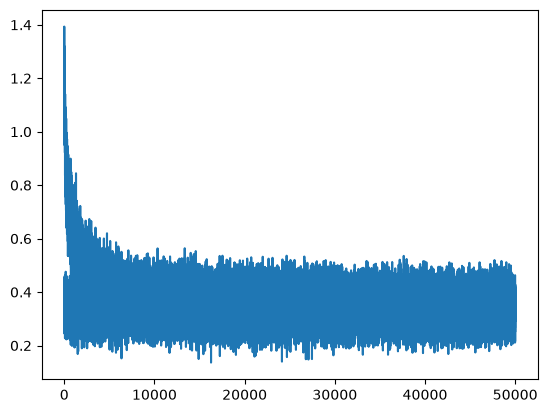

In [180]:
plt.plot(stepi, lossi)

In [181]:
#Train loss
emb = C[Xtr] #[32, 3, 2]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #[32, 100]
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ytr)   
loss

tensor(2.1745, grad_fn=<NllLossBackward0>)

In [182]:
#Dev loss
emb = C[Xdev] #[32, 3, 2]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1) #[32, 100]
logits = h @ W2 + b2
loss = F.cross_entropy(logits, ydev)   
loss

tensor(2.1983, grad_fn=<NllLossBackward0>)

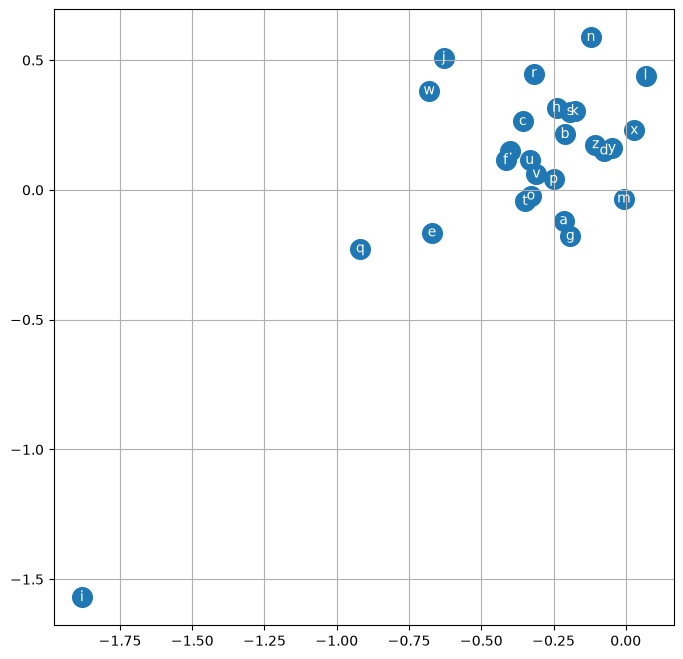

In [183]:
plt.figure(figsize=(8, 8))
plt.scatter(C[:, 0].data, C[:, 1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid("minor")

In [193]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    out = []
    context = [0] * block_size
    while True:
        emb = C[torch.tensor([context])]  
        h = torch.tanh(emb.view(1, -1) @ W1 + b1)
        logits = h @ W2 + b2
        probs = torch.softmax(logits, dim=1)
        ix = torch.multinomial(probs, num_samples=1, generator=g).item()
        context = context[1:] + [ix]
        out.append(ix)

        if ix == 0:
            break

    print(''.join(itos[i] for i in out))



carmah.
ambrilli.
kemrix.
taty.
salaysie.
rahnel.
delyah.
jareei.
nellara.
chaihe.
kaleigh.
ham.
join.
quinn.
suline.
liveni.
wazelo.
dearyn.
kai.
evidusabee.
